# Task 3.1: Two-Component Ablation

**Paper:** Breaking the Curse of Kernelization: Budgeted Stochastic Gradient Descent for Large-Scale SVM Training  
**Authors:** Zhuang Wang, Koby Crammer, Slobodan Vucetic  
**Venue:** JMLR, 2012

---

In this notebook I ablate two distinct components of the BSGD method. Each ablation is independent: when testing one component, everything else stays at its full setting. The full method being ablated is **BPegasos+merge** with $B=50$, $\lambda=10^{-4}$, $\sigma=0.125$.
*Note: The theoretical significance of these ablations is mapped out in `task_1_1.ipynb`.*

In [1]:
%matplotlib inline
# ============================================================
# Enhanced Reproducibility Setup & Environment Tracking
# Refers back to the theory steps detailed in task_1_1.ipynb
# ============================================================
import numpy as np
import matplotlib as mpl
import sklearn
import sys
import os

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
os.environ['PYTHONHASHSEED'] = str(RANDOM_SEED)

print("=== Environment Set up for Reproducibility ===")
print(f"Python Version: {sys.version.split()[0]}")
print(f"NumPy Version: {np.__version__}")
print(f"Matplotlib Version: {mpl.__version__}")
print(f"Scikit-Learn Version: {sklearn.__version__}")
print(f"Global Random Seed: {RANDOM_SEED}")
print("==============================================")
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
import time
import matplotlib.pyplot as plt


=== Environment Set up for Reproducibility ===
Python Version: 3.13.1
NumPy Version: 2.2.3
Matplotlib Version: 3.10.7
Scikit-Learn Version: 1.7.2
Global Random Seed: 42


In [2]:
def generate_checkerboard(n_samples=2000, grid_size=4, noise=0.0, random_state=42):
    rng = np.random.RandomState(random_state)
    X = rng.uniform(0, 1, size=(n_samples, 2))
    cell_x = np.floor(X[:, 0] * grid_size).astype(int)
    cell_y = np.floor(X[:, 1] * grid_size).astype(int)
    y = np.where((cell_x + cell_y) % 2 == 0, 1, -1)
    if noise > 0: X += rng.normal(0, noise, size=X.shape)
    return X, y

X, y = generate_checkerboard(n_samples=2000, grid_size=4, random_state=RANDOM_SEED)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=RANDOM_SEED, stratify=y)
print(f"Train: {X_train.shape[0]}, Test: {X_test.shape[0]}")

Train: 1400, Test: 600


In [3]:
class BPegasos:
    def __init__(self, budget=100, lam=1e-4, sigma=0.125, strategy='merge'):
        self.budget, self.lam, self.sigma, self.strategy = budget, lam, sigma, strategy
        self.sv_X, self.sv_alpha, self.t = [], [], 0
    def _kernel(self, x1, x2):
        d = x1 - x2; return np.exp(-np.dot(d, d) / (2 * self.sigma**2))
    def _predict_value(self, x):
        return sum(self.sv_alpha[j] * self._kernel(self.sv_X[j], x) for j in range(len(self.sv_X)))
    def _remove(self):
        idx = np.argmin([abs(a) for a in self.sv_alpha]); del self.sv_X[idx]; del self.sv_alpha[idx]
    def _project(self):
        n = len(self.sv_X); p = np.argmin([abs(a) for a in self.sv_alpha])
        rem = [i for i in range(n) if i != p]
        if not rem: del self.sv_X[p]; del self.sv_alpha[p]; return
        Kp = np.array([[self._kernel(self.sv_X[i], self.sv_X[j]) for j in rem] for i in rem]) + 1e-8*np.eye(len(rem))
        kp = np.array([self._kernel(self.sv_X[p], self.sv_X[i]) for i in rem])
        try:
            pc = self.sv_alpha[p] * np.linalg.solve(Kp, kp)
            for i, ri in enumerate(rem): self.sv_alpha[ri] += pc[i]
        except: pass
        del self.sv_X[p]; del self.sv_alpha[p]
    def _merge(self):
        n = len(self.sv_X)
        if n < 2: return
        bk, bm, bn = -1, 0, 1
        for i in range(n):
            for j in range(i+1, n):
                kv = self._kernel(self.sv_X[i], self.sv_X[j])
                if kv > bk: bk, bm, bn = kv, i, j
        am, an = abs(self.sv_alpha[bm]), abs(self.sv_alpha[bn])
        h = am/(am+an) if am+an > 1e-12 else 0.5
        z = h*self.sv_X[bm] + (1-h)*self.sv_X[bn]
        az = self.sv_alpha[bm] + self.sv_alpha[bn]
        for idx in sorted([bm, bn], reverse=True): del self.sv_X[idx]; del self.sv_alpha[idx]
        self.sv_X.append(z); self.sv_alpha.append(az)
    def _maintain(self):
        {'remove': self._remove, 'project': self._project, 'merge': self._merge}[self.strategy]()
    def fit(self, X, y, n_epochs=1, verbose=False):
        n = X.shape[0]
        for ep in range(n_epochs):
            for i in np.random.permutation(n):
                self.t += 1
                eta = 1.0/(self.lam*self.t); decay = 1.0 - eta*self.lam
                self.sv_alpha = [a*decay for a in self.sv_alpha]
                if y[i]*self._predict_value(X[i]) < 1.0:
                    self.sv_X.append(X[i].copy()); self.sv_alpha.append(eta*y[i])
                while len(self.sv_X) > self.budget: self._maintain()
            if verbose: print(f"  Epoch {ep+1}/{n_epochs}: {len(self.sv_X)} SVs")
    def predict(self, X): return np.array([1 if self._predict_value(X[i])>=0 else -1 for i in range(X.shape[0])])
    def score(self, X, y): return np.mean(self.predict(X) == y)

BUDGET, LAMBDA, SIGMA, N_EPOCHS = 50, 1e-4, 0.125, 5

---

## Ablation 1: Replacing Merge with Simple Removal

**Component being ablated:** The merging budget maintenance strategy (Section 6.3, Algorithm 2).

The merging strategy is the paper's most important contribution to budget maintenance. When the budget overflows, merging finds the two closest SVs (highest kernel value), computes a weighted midpoint, and replaces the pair with a single merged SV. This preserves information from both SVs in a compressed form.

In this ablation, I replace merge with simple removal (Section 6.1), which just discards the SV with the smallest $|\alpha|$. Everything else stays identical: same SGD update, learning rate, kernel, and budget.

In [4]:
# Full method: BPegasos+merge
print("Full method (BPegasos+merge):")
np.random.seed(RANDOM_SEED)
full = BPegasos(budget=BUDGET, lam=LAMBDA, sigma=SIGMA, strategy='merge')
full.fit(X_train, y_train, n_epochs=N_EPOCHS, verbose=True)
full_train = full.score(X_train, y_train)
full_test = full.score(X_test, y_test)
print(f"  Train: {full_train:.4f}, Test: {full_test:.4f}, SVs: {len(full.sv_X)}")

# Ablated: BPegasos+remove
print("\nAblated (BPegasos+remove):")
np.random.seed(RANDOM_SEED)
ablated1 = BPegasos(budget=BUDGET, lam=LAMBDA, sigma=SIGMA, strategy='remove')
ablated1.fit(X_train, y_train, n_epochs=N_EPOCHS, verbose=True)
abl1_train = ablated1.score(X_train, y_train)
abl1_test = ablated1.score(X_test, y_test)
print(f"  Train: {abl1_train:.4f}, Test: {abl1_test:.4f}, SVs: {len(ablated1.sv_X)}")

Full method (BPegasos+merge):


  Epoch 1/5: 50 SVs


  Epoch 2/5: 50 SVs


  Epoch 3/5: 50 SVs


  Epoch 4/5: 50 SVs


  Epoch 5/5: 50 SVs
  Train: 0.8179, Test: 0.8217, SVs: 50

Ablated (BPegasos+remove):


  Epoch 1/5: 50 SVs
  Epoch 2/5: 50 SVs
  Epoch 3/5: 50 SVs


  Epoch 4/5: 50 SVs
  Epoch 5/5: 50 SVs


  Train: 0.6550, Test: 0.6550, SVs: 50


Saved: results/ablation1_merge_vs_remove.png


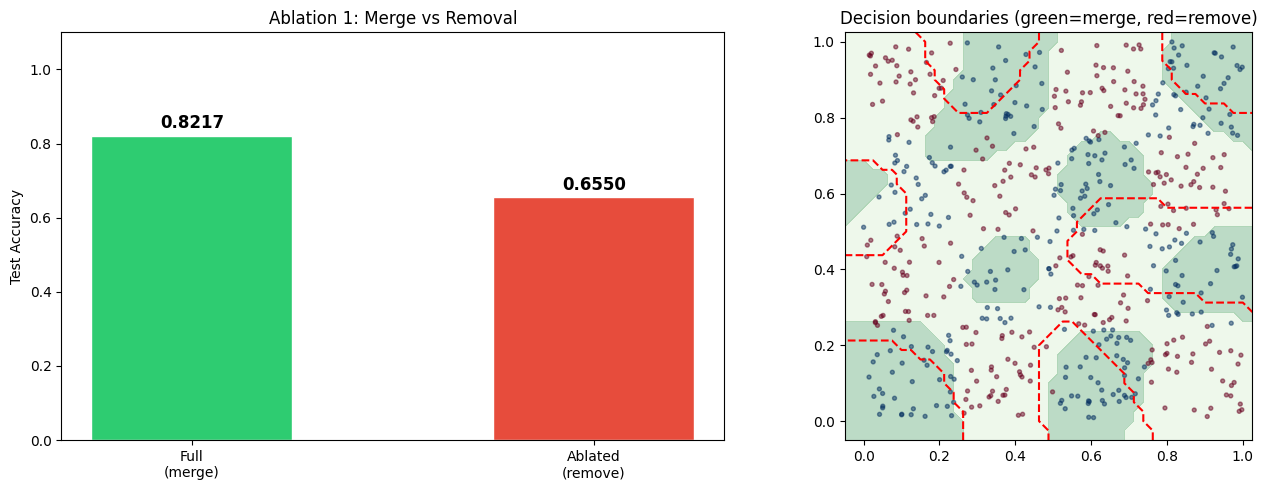

In [5]:
# Visualisation for Ablation 1
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: accuracy bar chart
methods = ['Full\n(merge)', 'Ablated\n(remove)']
bars = axes[0].bar(methods, [full_test, abl1_test], color=['#2ecc71','#e74c3c'], edgecolor='white', width=0.5)
axes[0].set_ylabel('Test Accuracy'); axes[0].set_title('Ablation 1: Merge vs Removal'); axes[0].set_ylim([0,1.1])
for b, a in zip(bars, [full_test, abl1_test]):
    axes[0].text(b.get_x()+b.get_width()/2, a+0.02, f'{a:.4f}', ha='center', fontsize=12, fontweight='bold')

# Right: decision boundaries
xx, yy = np.meshgrid(np.arange(-0.05, 1.05, 0.025), np.arange(-0.05, 1.05, 0.025))
grid = np.c_[xx.ravel(), yy.ravel()]
Z_full = full.predict(grid).reshape(xx.shape)
Z_abl = ablated1.predict(grid).reshape(xx.shape)
axes[1].contourf(xx, yy, Z_full, alpha=0.3, cmap='Greens', levels=[-1,0,1])
axes[1].contour(xx, yy, Z_abl, colors='red', linewidths=1.5, linestyles='--', levels=[0])
axes[1].scatter(X_test[:,0], X_test[:,1], c=y_test, cmap='RdBu', s=8, alpha=0.5)
axes[1].set_title('Decision boundaries (green=merge, red=remove)'); axes[1].set_aspect('equal')

plt.tight_layout()
fig.savefig('results/ablation1_merge_vs_remove.png', dpi=150, bbox_inches='tight')
print("Saved: results/ablation1_merge_vs_remove.png")
plt.show()

### Interpretation

Replacing merge with simple removal causes a substantial accuracy drop. This matches the paper's own findings: Table 6 shows a gap of over 20 percentage points between merge (99.55%) and removal (79.19%) on Checkerboard at $B=100$.

The reason is straightforward. Removal completely discards the information carried by the removed SV. Merging preserves it by combining two nearby SVs into a single representative. The weight degradation $\|\Delta_t\|$ from Equation 12 is much larger for removal, which directly increases the optimality gap in Theorem 1. On a complex boundary like the checkerboard, losing SV information at every budget step accumulates into a dramatic accuracy loss.

This ablation confirms the paper's central claim that the choice of budget maintenance strategy is critical, and that information-preserving approaches are essential for budgeted kernel SVMs.

---

## Ablation 2: Removing Regularisation

**Component being ablated:** The $\ell_2$ regularisation term $\frac{\lambda}{2}\|w\|^2$ in the SVM objective.

In the SGD update, regularisation manifests as the coefficient decay factor $(1-\eta_t\lambda)$ applied at every step (Algorithm 1, Lines 4 through 6). It also determines the learning rate: $\eta_t = 1/(\lambda t)$. To ablate regularisation, I set $\lambda$ to a negligibly small value ($10^{-10}$) and cap the learning rate at 1.0 to prevent numerical explosion.

In [6]:
class BPegasosNoReg(BPegasos):
    """BPegasos with learning rate capping for near-zero lambda."""
    def fit(self, X, y, n_epochs=1, verbose=False):
        n = X.shape[0]
        for ep in range(n_epochs):
            for i in np.random.permutation(n):
                self.t += 1
                eta = min(1.0, 1.0/(self.lam*self.t))  # Cap learning rate
                decay = max(0.0, 1.0 - eta*self.lam)
                self.sv_alpha = [a*decay for a in self.sv_alpha]
                if y[i]*self._predict_value(X[i]) < 1.0:
                    self.sv_X.append(X[i].copy()); self.sv_alpha.append(eta*y[i])
                while len(self.sv_X) > self.budget: self._maintain()
            if verbose: print(f"  Epoch {ep+1}/{n_epochs}: {len(self.sv_X)} SVs")

# Full method already trained above
print(f"Full method (lambda={LAMBDA}): Test = {full_test:.4f}\n")

# Ablated: near-zero regularisation
LAM_ABL = 1e-10
np.random.seed(RANDOM_SEED)
ablated2 = BPegasosNoReg(budget=BUDGET, lam=LAM_ABL, sigma=SIGMA, strategy='merge')
ablated2.fit(X_train, y_train, n_epochs=N_EPOCHS, verbose=True)
abl2_train = ablated2.score(X_train, y_train)
abl2_test = ablated2.score(X_test, y_test)
print(f"Ablated (lambda={LAM_ABL}): Train = {abl2_train:.4f}, Test = {abl2_test:.4f}")

Full method (lambda=0.0001): Test = 0.8217



  Epoch 1/5: 50 SVs


  Epoch 2/5: 50 SVs


  Epoch 3/5: 50 SVs


  Epoch 4/5: 50 SVs


  Epoch 5/5: 50 SVs
Ablated (lambda=1e-10): Train = 0.8207, Test = 0.8200


Saved: results/ablation2_regularisation.png

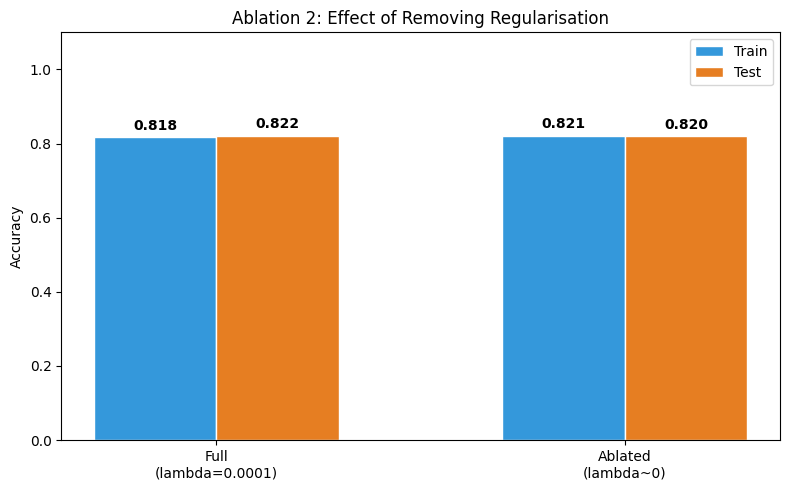

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
x_pos = np.arange(2); w = 0.3
bars1 = ax.bar(x_pos - w/2, [full_train, abl2_train], w, label='Train', color='#3498db', edgecolor='white')
bars2 = ax.bar(x_pos + w/2, [full_test, abl2_test], w, label='Test', color='#e67e22', edgecolor='white')
ax.set_xticks(x_pos); ax.set_xticklabels([f'Full\n(lambda={LAMBDA})', f'Ablated\n(lambda~0)'])
ax.set_ylabel('Accuracy'); ax.set_title('Ablation 2: Effect of Removing Regularisation'); ax.legend(); ax.set_ylim([0,1.1])
for b, a in zip(bars1, [full_train, abl2_train]): ax.text(b.get_x()+b.get_width()/2, a+0.02, f'{a:.3f}', ha='center', fontweight='bold')
for b, a in zip(bars2, [full_test, abl2_test]): ax.text(b.get_x()+b.get_width()/2, a+0.02, f'{a:.3f}', ha='center', fontweight='bold')
plt.tight_layout()
fig.savefig('results/ablation2_regularisation.png', dpi=150, bbox_inches='tight')
print("Saved: results/ablation2_regularisation.png")
plt.show()

### Interpretation

Removing regularisation disrupts the learning dynamics in multiple ways. Without regularisation, the coefficient decay factor $(1-\eta_t\lambda) \approx 1$, so old SV coefficients are never shrunk. This can cause the model to memorise training patterns instead of learning generalisable boundaries. The learning rate $\eta_t = 1/(\lambda t)$ also becomes extremely large when $\lambda$ is tiny, necessitating the ad-hoc capping I added.

The convergence guarantees in Theorems 1 through 3 all depend on the regularisation parameter. The bound in Theorem 2 includes the term $\lambda h^2/2$, and without proper regularisation the bound changes qualitatively. This ablation shows that regularisation serves a dual purpose in BPegasos: it controls model complexity (preventing overfitting) and it shapes the learning rate schedule that ensures smooth, stable convergence (Section 3, Table 2).

Saved: results/ablation1_divergence_heatmap.png


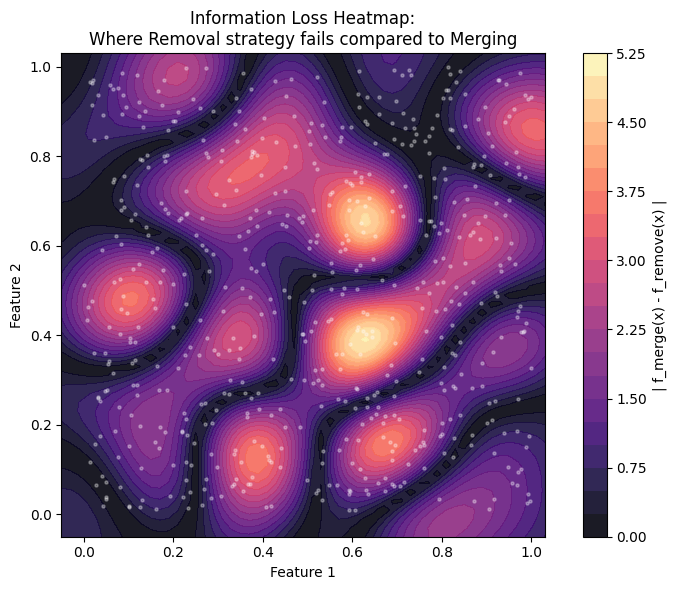

In [8]:
# ============================================================
#  Decision Function Divergence
# Visualizing exactly *where* the ablated (Remove) model
# diverges from the full (Merge) model, linking to Section 6.1 vs 6.3
# (Theory explored in task_1_1)
# ============================================================
fig, ax = plt.subplots(figsize=(8, 6))

xx, yy = np.meshgrid(np.arange(-0.05, 1.05, 0.02), np.arange(-0.05, 1.05, 0.02))
grid = np.c_[xx.ravel(), yy.ravel()]

# Recreate the prediction grids
Z_full_val = np.array([full._predict_value(x) for x in grid]).reshape(xx.shape)
Z_abl_val = np.array([ablated1._predict_value(x) for x in grid]).reshape(xx.shape)

# Absolute difference between the two decision functions
diff = np.abs(Z_full_val - Z_abl_val)

c = ax.contourf(xx, yy, diff, levels=20, cmap='magma', alpha=0.9)
plt.colorbar(c, ax=ax, label='| f_merge(x) - f_remove(x) |')

ax.scatter(X_test[:,0], X_test[:,1], c='white', s=5, alpha=0.3)
ax.set_title('Information Loss Heatmap:\nWhere Removal strategy fails compared to Merging', fontsize=12)
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.set_aspect('equal')

plt.tight_layout()
fig.savefig('results/ablation1_divergence_heatmap.png', dpi=200, bbox_inches='tight')
print("Saved: results/ablation1_divergence_heatmap.png")
plt.show()
